# A compiled train and evaluation step

Runnable locally on CPU or on a Cloud TPU VM.

- Choose a transparent train and held-out split
- Read the state transition in execution order
- Compute useful metrics without changing the model
- Make replay a controlled experiment

Training changes a model; evaluation should measure it without changing it. We’ll write those two steps separately and compile them with Flax NNX. Then we’ll check the parameters and optimizer counter before and after evaluation, so this important promise is something we test rather than assume.

## The idea

Training computes gradients and changes the model. Evaluation measures a fixed model under a declared input and scoring contract. Keeping those roles separate prevents held-out data from quietly participating in fitting.

## Evaluation observes a frozen model

Suppose validation loss improves after an accidental optimizer step on validation examples. The number is real, but it no longer evaluates the unchanged training result. The evaluation has influenced fitting.

Capture parameter and relevant state values before evaluation and compare afterward. If the model has training-only randomness or running statistics, verify its evaluation convention too. Depict only the mechanisms the actual model uses.

Aggregate evaluation contributions with their counts. Unequal batch sizes make an average of batch means different from an example mean. Finally, inspect actual errors in the held-out prediction field: a visually attractive boundary cannot rule out leakage or a denominator mistake.

### Pause and reason

Why compare state before and after evaluation instead of checking only the score?

<details><summary>Compare your reasoning</summary>

A score can look plausible even if evaluation updates parameters or statistics. State comparison tests whether the measurement changed the object it was meant to evaluate.

</details>

## Choose a transparent train and held-out split

Generate separate arrays from fixed independent seeds. Labels follow the known line x0 + $0.5$ x1 > $0$, so there is no label ambiguity and no external dataset download. Forty-eight training rows and forty-eight held-out rows are intentionally tiny. The held-out distribution matches the training distribution; this measures interpolation on a controlled problem, not robustness under distribution shift. Keep held-out rows out of optimizer calls. Real projects also need validation for model selection and a final test set; this example fixes hyperparameters in advance and does not supply a production evaluation protocol.

## Read the state transition in execution order

`nnx.value_and_grad` computes loss and gradients for the current parameters. `optimizer.update(model, grads)` then changes the model and optimizer state. The returned loss is pre-update loss, not the loss at the new weights. `nnx.Optimizer` is configured with `wrt=nnx.Param`, and `optax.adam` maintains first and second moments plus an update counter. A model snapshot alone cannot exactly resume Adam training. Conversely, a metrics call should not increment optimizer.step. Counting $80$ requested updates checks loop behavior, while comparing full snapshots checks evaluation isolation.

```text
(model parameters, optimizer state, training batch) → loss/gradients → updated model and optimizer
(fixed model, held-out batch) → loss and accuracy only
```

## Compute useful metrics without changing the model

Binary cross-entropy uses scores directly. Accuracy thresholds scores at zero; sigmoid is unnecessary for this decision. Return both because confidence and hard decisions measure different behavior. A wrong but extremely confident prediction can dominate loss while changing accuracy by only one observation. We calculate held-out loss independently with NumPy logaddexp and held-out accuracy with NumPy comparisons. Capture every parameter array before evaluation and compare bytes afterward. This model has no dropout or batch normalization; later stateful models require explicit evaluation mode and nonparameter-state checks too.

## Make replay a controlled experiment

Repeat the full initialization and training routine from the same seed and batches. Compare final parameter arrays within tolerance and compare held-out metrics. This is stronger than checking that one seeded initialization looks similar. It verifies the sequence of updates, but only in the tested CPU environment. Floating-point reductions, package versions, and backend changes may affect results. Store model seed, data seeds, batch policy, learning rate, iteration count, dependency versions, and metrics. Do not use a different initialization as a supposed resume of an existing optimizer state.

## 1. Construct data, model, and optimizer

Create main.py in the training dependency environment. The generator returns separate train and held-out arrays.

In [1]:
# Step 1 — 1. Construct data, model, and optimizer: The held-out seed is 11; every optimizer call below uses seed-10...
# Import flax (nnx) for this computation.
from flax import nnx
import jax
import jax.numpy as jnp
import numpy as np
import optax
# Function `dataset(seed, n)` implementing this stage's computation:
def dataset(seed,n=48):
    # Cast or evaluate `a` in explicit floating-point precision.
    a=np.random.default_rng(seed).normal(size=(n,2)).astype(np.float32)
    # Cast or evaluate `b` in explicit floating-point precision.
    b=(a[:,0]+.5*a[:,1]>0).astype(np.float32)
    # Return `(jnp.array(a), jnp.array(b))` to the caller.
    return jnp.array(a),jnp.array(b)
# Run `dataset` to compute `(train_x, train_y)`.
train_x,train_y=dataset(10)
# Run `dataset` to compute `(test_x, test_y)`.
test_x,test_y=dataset(11)
# Define `Classifier` module / container with explicit state and forward pass:
class Classifier(nnx.Module):
    # Function `__init__(self, seed)` implementing this stage's computation:
    def __init__(self,seed=0):
        # Run `nnx.Rngs` to compute `rngs`.
        rngs=nnx.Rngs(seed)
        # Run `nnx.Linear` to compute `self.hidden`.
        self.hidden=nnx.Linear(2,8,rngs=rngs)
        # Run `nnx.Linear` to compute `self.out`.
        self.out=nnx.Linear(8,1,rngs=rngs)
    # Function `__call__(self, x)` implementing this stage's computation:
    # Return `self.out(nnx.tanh(self.hidden(x))).squeeze(-1)` to the caller.
    def __call__(self,x):return self.out(nnx.tanh(self.hidden(x))).squeeze(-1)
# Function `objective(m, x, y)` implementing this stage's computation:
# Return `jnp.mean(optax.sigmoid_binary_cross_entropy(m(x), y))` to the caller.
def objective(m,x,y):return jnp.mean(optax.sigmoid_binary_cross_entropy(m(x),y))
# Function `initialize()` implementing this stage's computation:
def initialize():
    # Run `Classifier` to compute `m`.
    m=Classifier(0)
    # Return `(m, nnx.Optimizer(m, optax.adam(0.03), wrt=nnx.Param))` to the caller.
    return m,nnx.Optimizer(m,optax.adam(.03),wrt=nnx.Param)
# Run `initialize` to compute `(model, optimizer)`.
model,optimizer=initialize()

The held-out seed is $11$; every optimizer call below uses seed-10 data only.

## 2. Define the two compiled functions

Append train and evaluation functions. Notice that only train_step receives an optimizer.

In [2]:
# Step 2 — 2. Define the two compiled functions: The 80-update counter is an optimizer invariant.
# Define and JIT-compile `train_step(m, o, x, y)` so XLA traces and fuses the operations:
@nnx.jit
# Function `train_step(m, o, x, y)` implementing this stage's computation:
def train_step(m,o,x,y):
    # Differentiate the objective to obtain `(value, grads)` via automatic differentiation.
    value,grads=nnx.value_and_grad(objective)(m,x,y)
    # Update state in place with the new values.
    o.update(m,grads)
    # Return `value` to the caller.
    return value
# Define and JIT-compile `evaluate(m, x, y)` so XLA traces and fuses the operations:
@nnx.jit
# Function `evaluate(m, x, y)` implementing this stage's computation:
def evaluate(m,x,y):
    # Run `m` to compute `scores`.
    scores=m(x)
    # Return `(jnp.mean(optax.sigmoid_binary_cross_entropy(scores, y)), jnp.mean((scores > 0) == y))` to the caller.
    return jnp.mean(optax.sigmoid_binary_cross_entropy(scores,y)),jnp.mean((scores>0)==y)
# Function `snapshot(m)` implementing this stage's computation:
# Return `[np.array(a, copy=True) for a in jax.tree.leaves(nnx.state(m))]` to the caller.
def snapshot(m):return [np.array(a,copy=True) for a in jax.tree.leaves(nnx.state(m))]
# Evaluate `objective(model, train_x, train_y)` and convert the result into Python scalar/collection `before_loss`.
before_loss=float(objective(model,train_x,train_y))
# Repeat the update loop over `range(80)` steps:
# Execute the next step of the computation.
for _ in range(80):train_step(model,optimizer,train_x,train_y)
# Verify contract: `int(optimizer.step[...]) == 80`.
assert int(optimizer.step[...])==80

The 80-update counter is an optimizer invariant. Pre-update losses returned during the loop are not the final held-out metric.

## 3. Verify held-out metrics and state isolation

Append snapshot and reference comparisons. Print both training and held-out results instead of a single success number.

In [3]:
# Step 3 — 3. Verify held-out metrics and state isolation: The synthetic fixture normally exceeds 0.85 held-out accuracy.
frozen=snapshot(model);step_count=int(optimizer.step[...])
# Run `evaluate` to compute `(test_loss, test_accuracy)`.
test_loss,test_accuracy=evaluate(model,test_x,test_y)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(frozen,snapshot(model)):np.testing.assert_array_equal(a,b)
# Verify contract: `int(optimizer.step[...]) == step_count`.
assert int(optimizer.step[...])==step_count
# Convert `scores` to a host NumPy array for inspection or verification.
# Convert `labels` to a host NumPy array for inspection or verification.
scores=np.asarray(model(test_x));labels=np.asarray(test_y)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(test_loss,np.mean(np.logaddexp(0.,scores)-labels*scores),rtol=1e-5,atol=1e-6)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(test_accuracy,np.mean((scores>0)==labels),atol=1e-6)
# Verify contract: `float(test_accuracy) > 0.85 and float(objective(model, train_x, trai...`.
assert float(test_accuracy)>.85 and float(objective(model,train_x,train_y))<before_loss*.3
# Print the observed values to compare against the expected result.
print('Updates:',step_count,'held-out loss:',float(test_loss),'accuracy:',float(test_accuracy))

Updates: 80 held-out loss: 0.018426384776830673 accuracy: 1.0


The synthetic fixture normally exceeds $0.85$ held-out accuracy. Parameter bytes and optimizer count remain unchanged during evaluation.

## Run the example

In [4]:
# Step 1 — 1. Construct data, model, and optimizer: The held-out seed is 11; every optimizer call below uses seed-10...
# Import flax (nnx) for this computation.
from flax import nnx
import jax
import jax.numpy as jnp
import numpy as np
import optax
# Function `dataset(seed, n)` implementing this stage's computation:
def dataset(seed,n=48):
    # Cast or evaluate `a` in explicit floating-point precision.
    a=np.random.default_rng(seed).normal(size=(n,2)).astype(np.float32)
    # Cast or evaluate `b` in explicit floating-point precision.
    b=(a[:,0]+.5*a[:,1]>0).astype(np.float32)
    # Return `(jnp.array(a), jnp.array(b))` to the caller.
    return jnp.array(a),jnp.array(b)
# Run `dataset` to compute `(train_x, train_y)`.
train_x,train_y=dataset(10)
# Run `dataset` to compute `(test_x, test_y)`.
test_x,test_y=dataset(11)
# Define `Classifier` module / container with explicit state and forward pass:
class Classifier(nnx.Module):
    # Function `__init__(self, seed)` implementing this stage's computation:
    def __init__(self,seed=0):
        # Run `nnx.Rngs` to compute `rngs`.
        rngs=nnx.Rngs(seed)
        # Run `nnx.Linear` to compute `self.hidden`.
        self.hidden=nnx.Linear(2,8,rngs=rngs)
        # Run `nnx.Linear` to compute `self.out`.
        self.out=nnx.Linear(8,1,rngs=rngs)
    # Function `__call__(self, x)` implementing this stage's computation:
    # Return `self.out(nnx.tanh(self.hidden(x))).squeeze(-1)` to the caller.
    def __call__(self,x):return self.out(nnx.tanh(self.hidden(x))).squeeze(-1)
# Function `objective(m, x, y)` implementing this stage's computation:
# Return `jnp.mean(optax.sigmoid_binary_cross_entropy(m(x), y))` to the caller.
def objective(m,x,y):return jnp.mean(optax.sigmoid_binary_cross_entropy(m(x),y))
# Function `initialize()` implementing this stage's computation:
def initialize():
    # Run `Classifier` to compute `m`.
    m=Classifier(0)
    # Return `(m, nnx.Optimizer(m, optax.adam(0.03), wrt=nnx.Param))` to the caller.
    return m,nnx.Optimizer(m,optax.adam(.03),wrt=nnx.Param)
# Run `initialize` to compute `(model, optimizer)`.
model,optimizer=initialize()

# Step 2 — 2. Define the two compiled functions: The 80-update counter is an optimizer invariant.
# Define and JIT-compile `train_step(m, o, x, y)` so XLA traces and fuses the operations:
@nnx.jit
# Function `train_step(m, o, x, y)` implementing this stage's computation:
def train_step(m,o,x,y):
    # Differentiate the objective to obtain `(value, grads)` via automatic differentiation.
    value,grads=nnx.value_and_grad(objective)(m,x,y)
    # Update state in place with the new values.
    o.update(m,grads)
    # Return `value` to the caller.
    return value
# Define and JIT-compile `evaluate(m, x, y)` so XLA traces and fuses the operations:
@nnx.jit
# Function `evaluate(m, x, y)` implementing this stage's computation:
def evaluate(m,x,y):
    # Run `m` to compute `scores`.
    scores=m(x)
    # Return `(jnp.mean(optax.sigmoid_binary_cross_entropy(scores, y)), jnp.mean((scores > 0) == y))` to the caller.
    return jnp.mean(optax.sigmoid_binary_cross_entropy(scores,y)),jnp.mean((scores>0)==y)
# Function `snapshot(m)` implementing this stage's computation:
# Return `[np.array(a, copy=True) for a in jax.tree.leaves(nnx.state(m))]` to the caller.
def snapshot(m):return [np.array(a,copy=True) for a in jax.tree.leaves(nnx.state(m))]
# Evaluate `objective(model, train_x, train_y)` and convert the result into Python scalar/collection `before_loss`.
before_loss=float(objective(model,train_x,train_y))
# Repeat the update loop over `range(80)` steps:
# Execute the next step of the computation.
for _ in range(80):train_step(model,optimizer,train_x,train_y)
# Verify contract: `int(optimizer.step[...]) == 80`.
assert int(optimizer.step[...])==80

# Step 3 — 3. Verify held-out metrics and state isolation: The synthetic fixture normally exceeds 0.85 held-out accuracy.
frozen=snapshot(model);step_count=int(optimizer.step[...])
# Run `evaluate` to compute `(test_loss, test_accuracy)`.
test_loss,test_accuracy=evaluate(model,test_x,test_y)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(frozen,snapshot(model)):np.testing.assert_array_equal(a,b)
# Verify contract: `int(optimizer.step[...]) == step_count`.
assert int(optimizer.step[...])==step_count
# Convert `scores` to a host NumPy array for inspection or verification.
# Convert `labels` to a host NumPy array for inspection or verification.
scores=np.asarray(model(test_x));labels=np.asarray(test_y)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(test_loss,np.mean(np.logaddexp(0.,scores)-labels*scores),rtol=1e-5,atol=1e-6)
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(test_accuracy,np.mean((scores>0)==labels),atol=1e-6)
# Verify contract: `float(test_accuracy) > 0.85 and float(objective(model, train_x, trai...`.
assert float(test_accuracy)>.85 and float(objective(model,train_x,train_y))<before_loss*.3
# Print the observed values to compare against the expected result.
print('Updates:',step_count,'held-out loss:',float(test_loss),'accuracy:',float(test_accuracy))

Updates: 80 held-out loss: 0.018426384776830673 accuracy: 1.0


Expected: $80$ optimizer updates; held-out accuracy above $0.85$; evaluation snapshots unchanged. Exact scalar metrics are printed by your run.

## Inspect predictions on held-out inputs

Predict: Where would a mistake appear relative to the decision boundary?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Inspect predictions on held-out inputs
# Generate a uniform grid of points in `axis`.
axis = jnp.linspace(-3.0, 3.0, 61)
# Run `jnp.meshgrid` to compute `(gx, gy)`.
gx, gy = jnp.meshgrid(axis, axis)
# Combine or mask array elements to form `grid`.
grid = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)
# Rearrange tensor axes to match the required layout for `prob`.
prob = jax.nn.sigmoid(model(grid)).reshape(gx.shape)
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'field', 'values': prob.tolist(), 'extent': [-3.0, 3.0, -3.0, 3.0], 'xlabel': 'feature 0', 'ylabel': 'feature 1', 'unit': 'P(label 1)', 'points': test_x.tolist(), 'labels': test_y.tolist()}

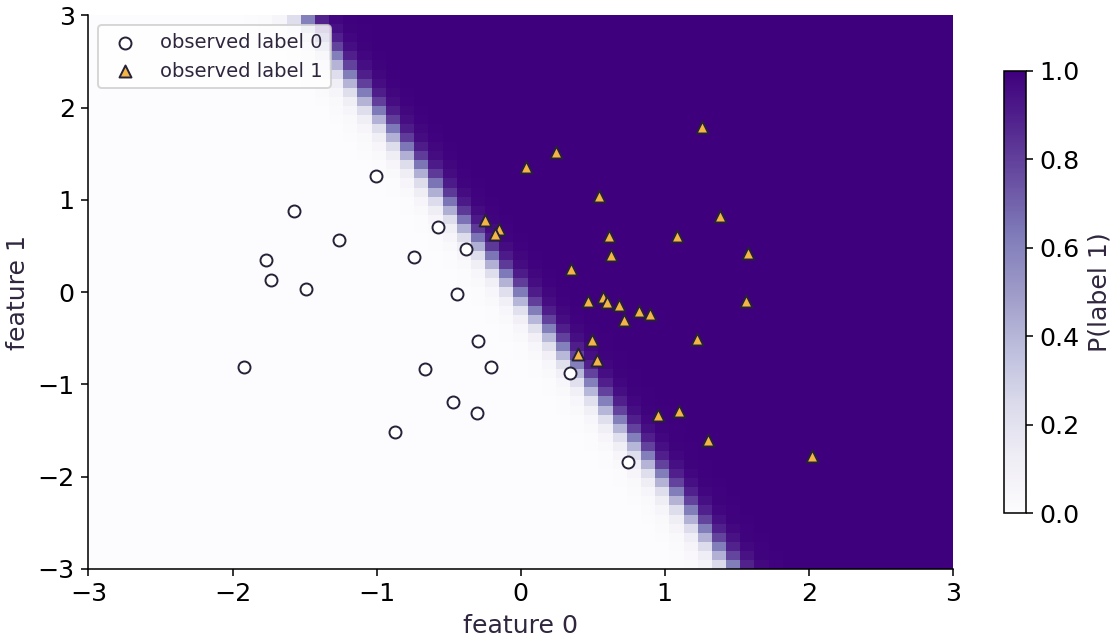

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal and vertical axes are input features. The background is the trained model’s probability of label $1$, from pale near $0$ to dark purple near $1$. Circles mark held-out examples with label $0$, and triangles mark held-out examples with label $1$.

A slanted transition separates a mostly pale left side from a dark right side. The circles lie on the low-probability side and the triangles on the high-probability side. The example’s direct evaluation reports accuracy $1$ on this fixed held-out set; the figure shows where those correct decisions occur.

### Connect it to the computation

The data rule assigns label $1$ when $x_0+0.5x_1>0$, whose boundary is $x_1=-2x_0$. That explains the overall downward slant. The network approximates this separation; its transition need not be perfectly straight everywhere.

To inspect a mistake in a changed run, look for a triangle where the probability is below $0.5$, or a circle where it is above $0.5$, and check the model at that exact point. Grid colors are sampled approximations. Perfect accuracy on this small synthetic set does not establish accuracy outside it, and extreme probabilities do not by themselves establish calibration.

## Replay the complete update sequence

Predict: Should equal seed, batches, and update count reproduce the final model?

In [7]:
# Experiment — Replay the complete update sequence: Replay reconstructs optimizer state from the start.
replay,replay_optimizer=initialize()
# Repeat the update loop over `range(80)` steps:
# Execute the next step of the computation.
for _ in range(80):train_step(replay,replay_optimizer,train_x,train_y)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(snapshot(model),snapshot(replay)):np.testing.assert_allclose(a,b,rtol=1e-6,atol=1e-6)
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(evaluate(replay,test_x,test_y),evaluate(model,test_x,test_y),rtol=1e-6)

Expected: Final parameters and held-out metrics agree within CPU tolerances.

Replay reconstructs optimizer state from the start. It is not a checkpoint-resume implementation.

## Duplicating evaluation data

Predict: If the held-out rows are repeated twice, should mean loss or accuracy change?

In [8]:
# Experiment — Duplicating evaluation data: Means normalize the observation count.
doubled=evaluate(model,jnp.concatenate([test_x,test_x]),jnp.concatenate([test_y,test_y]))
# Verify that computed values match the expected reference within numerical tolerance.
np.testing.assert_allclose(doubled,evaluate(model,test_x,test_y),rtol=1e-5,atol=1e-6)

Expected: Both metrics stay the same.

Means normalize the observation count. Duplicating data does not create independent evaluation evidence.

## Your exercise

Compute held-out metrics in three equal chunks and reconstruct the overall means. Then confirm no state changed.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Evaluate `pieces` from the current inputs and state.
2. Reduce along axis=0 to compute `aggregate`.
3. Convert `` to a host NumPy array for inspection or verification.
4. Iterate over `(a, b)` to step through the computation:

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compute held-out metrics in three equal chunks and reconstruct the...
old = snapshot(...)  # TODO: compute old
# Evaluate `pieces` from the current inputs and state.
pieces = ...  # TODO: compute pieces
# Reduce along axis=0 to compute `aggregate`.
aggregate = np.mean(...)  # TODO: compute aggregate
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(aggregate,np.asarray(evaluate(model,test_x,test_y)),rtol = ...  # TODO: compute np.testing.assert_allclose(aggregate,np.asarray(evaluate(model,test_x,test_y)),rtol
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(old,snapshot(model)):np.testing.assert_array_equal(a,b)
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compute held-out metrics in three equal chunks and reconstruct the...
# old = snapshot(...)  # TODO: compute old
# Evaluate `pieces` from the current inputs and state.
# pieces = ...  # TODO: compute pieces
# Reduce along axis=0 to compute `aggregate`.
# aggregate = np.mean(...)  # TODO: compute aggregate
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(aggregate,np.asarray(evaluate(model,test_x,test_y)),rtol = ...  # TODO: compute np.testing.assert_allclose(aggregate,np.asarray(evaluate(model,test_x,test_y)),rtol
# Iterate over `(a, b)` to step through the computation:
# for a,b in zip(old,snapshot(model)):np.testing.assert_array_equal(a,b)

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Compute held-out metrics in three equal chunks and reconstruct the...
old=snapshot(model)
# Evaluate `pieces` from the current inputs and state.
pieces=[evaluate(model,test_x[i:i+16],test_y[i:i+16]) for i in range(0,48,16)]
# Reduce along axis=0 to compute `aggregate`.
aggregate=np.mean(np.asarray(pieces),axis=0)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(aggregate,np.asarray(evaluate(model,test_x,test_y)),rtol=1e-5,atol=1e-6)
# Iterate over `(a, b)` to step through the computation:
for a,b in zip(old,snapshot(model)):np.testing.assert_array_equal(a,b)

## Aggregate unequal batches · Transfer

Evaluate the held-out set in batches of seven and forty-one observations. Reconstruct both metrics from sums and counts. Use a separate constructed count example to demonstrate why averaging batch accuracies can be wrong.

Hint: Weight each batch mean by its number of observations.

### How to write: Aggregate unequal batches — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `sizes` with explicit values and shape.
2. Convert `metrics` to a host NumPy array for inspection or verification.
3. Reduce along axis=0 to compute `weighted`.
4. Convert `` to a host NumPy array for inspection or verification.
5. Initialize array `correct` with explicit values and shape.

**Starter code scaffold (fill in the TODOs):**

```python
# Aggregate unequal batches (Transfer): A batch is a packaging choice, not a unit of evidence.
# Initialize array `sizes` with explicit values and shape.
sizes = np.array(...)  # TODO: compute sizes
# Convert `metrics` to a host NumPy array for inspection or verification.
metrics = np.asarray(...)  # TODO: compute metrics
# Reduce along axis=0 to compute `weighted`.
weighted = ...  # TODO: compute weighted
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(weighted,np.asarray(evaluate(model,test_x,test_y)),rtol = ...  # TODO: compute np.testing.assert_allclose(weighted,np.asarray(evaluate(model,test_x,test_y)),rtol
# Initialize array `correct` with explicit values and shape.
correct = np.array(...)  # TODO: compute correct
# Evaluate `expected` from the current inputs and state.
expected = ...  # TODO: compute expected
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(correct.sum()/counts.sum(),expected)
# Verify that the numerical values match the expected reference within tolerance.
assert not np.isclose(np.mean(correct/counts),expected)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Count-weighted held-out metrics:',weighted,'constructed accuracy:',expected)
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Aggregate unequal batches (Transfer): A batch is a packaging choice, not a unit of evidence.
# Initialize array `sizes` with explicit values and shape.
# sizes = np.array(...)  # TODO: compute sizes
# Convert `metrics` to a host NumPy array for inspection or verification.
# metrics = np.asarray(...)  # TODO: compute metrics
# Reduce along axis=0 to compute `weighted`.
# weighted = ...  # TODO: compute weighted
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(weighted,np.asarray(evaluate(model,test_x,test_y)),rtol = ...  # TODO: compute np.testing.assert_allclose(weighted,np.asarray(evaluate(model,test_x,test_y)),rtol
# Initialize array `correct` with explicit values and shape.
# correct = np.array(...)  # TODO: compute correct
# Evaluate `expected` from the current inputs and state.
# expected = ...  # TODO: compute expected
# Reduce across the target axis to summarize ``.
# np.testing.assert_allclose(correct.sum()/counts.sum(),expected)
# Verify that the numerical values match the expected reference within tolerance.
# assert not np.isclose(np.mean(correct/counts),expected)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Count-weighted held-out metrics:',weighted,'constructed accuracy:',expected)

## Reference reasoning

A batch is a packaging choice, not a unit of evidence. The constructed counts expose the bias even if a particular model happens to obtain equal accuracy on both actual batches.

In [12]:
# Aggregate unequal batches (Transfer): A batch is a packaging choice, not a unit of evidence.
# Initialize array `sizes` with explicit values and shape.
sizes=np.array([7,41])
# Convert `metrics` to a host NumPy array for inspection or verification.
metrics=np.asarray([evaluate(model,test_x[:7],test_y[:7]),evaluate(model,test_x[7:],test_y[7:])])
# Reduce along axis=0 to compute `weighted`.
weighted=(metrics*sizes[:,None]).sum(axis=0)/sizes.sum()
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(weighted,np.asarray(evaluate(model,test_x,test_y)),rtol=1e-5,atol=1e-6)
# Initialize array `correct` with explicit values and shape.
correct=np.array([6,20]);counts=np.array([7,41])
# Evaluate `expected` from the current inputs and state.
expected=26/48
# Reduce across the target axis to summarize ``.
np.testing.assert_allclose(correct.sum()/counts.sum(),expected)
# Verify that the numerical values match the expected reference within tolerance.
assert not np.isclose(np.mean(correct/counts),expected)
# Print the observed values to compare against the expected result.
print('Count-weighted held-out metrics:',weighted,'constructed accuracy:',expected)

Count-weighted held-out metrics: [0.01842638 0.99999995] constructed accuracy: 0.5416666666666666


## Catch an evaluation function that trains · Intermediate

On an independent clone, deliberately call train_step with held-out data and show the isolation checks fail. Keep the real model untouched.

Hint: Compare both optimizer.step and model parameters around the bad call.

### How to write: Catch an evaluation function that trains — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jax.tree.map(lambda p, g: ..., params, grads)` — Applies a function leaf-by-leaf across matching PyTrees (such as updating every parameter tensor with its gradient).
- `nnx.Module / nnx.Linear / nnx.Optimizer` — Flax NNX stateful module and optimizer containers with explicit RNG streams (`nnx.Rngs`) and traced graph updates.
- `optax.adam(lr) / optax.apply_updates(params, updates)` — Optax gradient transformations and numerically stable loss functions over parameter PyTrees.

**Step-by-step implementation plan:**
1. Catch an evaluation function that trains (Intermediate): A plausible returned loss does not establish evaluation.
2. Transform every leaf of the parameter PyTree (`bad_model`).
3. Configure or step the Optax optimizer state (`bad_optimizer`).
4. Run `snapshot` to compute `prior`.
5. Run `train_step` to perform the next check or state transition.

**Starter code scaffold (fill in the TODOs):**

```python
# Catch an evaluation function that trains (Intermediate): A plausible returned loss does not establish evaluation.
graph,state = nnx.split(...)  # TODO: compute graph,state
# Transform every leaf of the parameter PyTree (`bad_model`).
bad_model = nnx.merge(...)  # TODO: compute bad_model
# Configure or step the Optax optimizer state (`bad_optimizer`).
bad_optimizer = nnx.Optimizer(...)  # TODO: compute bad_optimizer
# Run `snapshot` to compute `prior`.
prior = snapshot(...)  # TODO: compute prior
# Run `train_step` to perform the next check or state transition.
train_step(bad_model,bad_optimizer,test_x,test_y)
# Verify contract: `int(bad_optimizer.step[...]) == 1`.
assert int(bad_optimizer.step[...])  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert any(not np.array_equal(a,b) for a,b  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert int(optimizer.step[...])  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Catch an evaluation function that trains (Intermediate): A plausible returned loss does not establish evaluation.
# graph,state = nnx.split(...)  # TODO: compute graph,state
# Transform every leaf of the parameter PyTree (`bad_model`).
# bad_model = nnx.merge(...)  # TODO: compute bad_model
# Configure or step the Optax optimizer state (`bad_optimizer`).
# bad_optimizer = nnx.Optimizer(...)  # TODO: compute bad_optimizer
# Run `snapshot` to compute `prior`.
# prior = snapshot(...)  # TODO: compute prior
# Run `train_step` to perform the next check or state transition.
# train_step(bad_model,bad_optimizer,test_x,test_y)
# Verify contract: `int(bad_optimizer.step[...]) == 1`.
# assert int(bad_optimizer.step[...])  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert any(not np.array_equal(a,b) for a,b  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert int(optimizer.step[...])  # TODO: complete assertion check

## Reference reasoning

A plausible returned loss does not establish evaluation. Passing held-out data through the update function leaks it into learned state.

In [14]:
# Catch an evaluation function that trains (Intermediate): A plausible returned loss does not establish evaluation.
graph,state=nnx.split(model)
# Transform every leaf of the parameter PyTree (`bad_model`).
bad_model=nnx.merge(graph,jax.tree.map(lambda a:jnp.array(a,copy=True),state))
# Configure or step the Optax optimizer state (`bad_optimizer`).
bad_optimizer=nnx.Optimizer(bad_model,optax.adam(.03),wrt=nnx.Param)
# Run `snapshot` to compute `prior`.
prior=snapshot(bad_model)
# Run `train_step` to perform the next check or state transition.
train_step(bad_model,bad_optimizer,test_x,test_y)
# Verify contract: `int(bad_optimizer.step[...]) == 1`.
assert int(bad_optimizer.step[...])==1
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert any(not np.array_equal(a,b) for a,b in zip(prior,snapshot(bad_model)))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert int(optimizer.step[...])==80

## Checkpoint

The train step returns a loss before optimizer.update. Which parameters does it describe?

1. The parameters entering that update
2. The final parameters after all updates
3. A separate held-out model

## Diagnose

If metrics look suspiciously good, trace which arrays reach train_step. If evaluation modifies the model, compare snapshots and optimizer counts. If replay fails, compare data seeds, iteration counts, optimizer initialization, and versions before guessing that compilation is nondeterministic.

## Evidence

Keep pre/post parameter snapshots around evaluation, optimizer step count 80, independent held-out loss and accuracy, complete replay comparison, and a deliberately bad held-out update on an isolated clone.

## Carry forward

- Choose a transparent train and held-out split
- Read the state transition in execution order
- Compute useful metrics without changing the model
- Make replay a controlled experiment

## Primary references

- [NNX optimizer API](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/training/optimizer.html)
- [NNX transforms](https://flax.readthedocs.io/en/latest/guides/transforms.html)